In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
size_text =24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w = 10
h = 6

# dataset

In [ ]:
df = pd.read_csv("Case_1.csv")
X = df[["h", "k", "d"]].values
y = df["F"].values.reshape(-1, 1)

# train - test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Scaling

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

In [ ]:
valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)
H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)

# Polynomial model with interactions (degree 3)

In [ ]:
grado =3

In [ ]:
poly = PolynomialFeatures(degree=grado)
X_poly = poly.fit_transform(X_train_scaled)


modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y_train_scaled)

# Transformacion de datos de entrenamiento y test
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# predicciones conjunto train
y_pred_regresion_train = modelo_poly.predict(X_train_poly)
# Predcciones conjunto test
y_pred_regresion_test = modelo_poly.predict(X_test_poly)

# Medir los tiempos

In [ ]:
import time  # lo pones una sola vez al inicio del script/notebook

# ================= TIEMPO ENTRENAMIENTO =================
t0 = time.perf_counter()

poly = PolynomialFeatures(degree=grado)
X_poly = poly.fit_transform(X_train_scaled)

modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y_train_scaled)

t1 = time.perf_counter()
T_train_poly = t1 - t0
print(f"⏱️ Tiempo entrenamiento (poly + LinearRegression): {T_train_poly:.6f} s")

# ================= TIEMPO PREDICCIÓN =================
t2 = time.perf_counter()

# Transformacion de datos de entrenamiento y test
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# predicciones conjunto train
y_pred_regresion_train = modelo_poly.predict(X_train_poly)
# Predcciones conjunto test
y_pred_regresion_test = modelo_poly.predict(X_test_poly)

t3 = time.perf_counter()
T_pred_poly = t3 - t2
N_pred = X_test_scaled.shape[0]
t_pred_por_muestra = T_pred_poly / N_pred

print(f"⏱️ Tiempo predicción total (test): {T_pred_poly:.6f} s para {N_pred} muestras")
print(f"⏱️ Tiempo por predicción: {t_pred_por_muestra:.8f} s/muestra")

⏱️ Tiempo entrenamiento (poly + LinearRegression): 0.143107 s
⏱️ Tiempo predicción total (test): 0.020339 s para 7500 muestras
⏱️ Tiempo por predicción: 0.00000271 s/muestra


In [ ]:
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)
X_pred_poly = poly.transform(X_pred_scaled)

# Predicción sobre la grilla
F_poly_scaled = modelo_poly.predict(X_pred_poly)
F_poly = scaler_y.inverse_transform(F_poly_scaled.reshape(-1, 1)).reshape(H.shape)

# Data inverse scaling for testing

In [ ]:
y_train_real = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).ravel()
y_pred_train_real = scaler_y.inverse_transform(y_pred_regresion_train.reshape(-1, 1)).ravel()

y_test_real = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()
y_pred_test_real = scaler_y.inverse_transform(y_pred_regresion_test.reshape(-1, 1)).ravel()

# Metrics

# Metrics for training

In [ ]:
mse_train = mean_squared_error(y_train_real,y_pred_train_real)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_real, y_pred_train_real)
r2_train = r2_score(y_train_real, y_pred_train_real)

print(mse_train)
print(rmse_train)
print(mae_train)
print(r2_train)

2.0585022028162212e-14
1.4347481321877444e-07
8.764454959595493e-08
0.9664206344089722


# Metrics for testing

In [ ]:
mse_test = mean_squared_error(y_test_real, y_pred_test_real)
rmse_test = np.sqrt(mse_test)
mae_test = mae_train = mean_absolute_error(y_test_real, y_pred_test_real)
r2_test = r2_score(y_test_real, y_pred_test_real)

print(mse_test)
print(rmse_test)
print(mae_test)
print(r2_test)

2.0715133441463632e-14
1.439275284351942e-07
8.849432741466016e-08
0.9658012138065768


# mape

In [ ]:
mape2 = np.mean(np.abs((y_test_real - y_pred_test_real) / y_test_real)) * 100
print(f"Error porcentual promedio (MAPE): {mape2:.2f}%")

Error porcentual promedio (MAPE): 7.13%


In [ ]:
tolerancia = 0.05  # 5%
porcentaje_buenas2 = np.mean(np.abs((y_test_real - y_pred_test_real) / y_test_real) < tolerancia) * 100
print(f"Predicciones con menos de 5% de error: {porcentaje_buenas2:.2f}%")

Predicciones con menos de 5% de error: 61.03%


# Learning curves

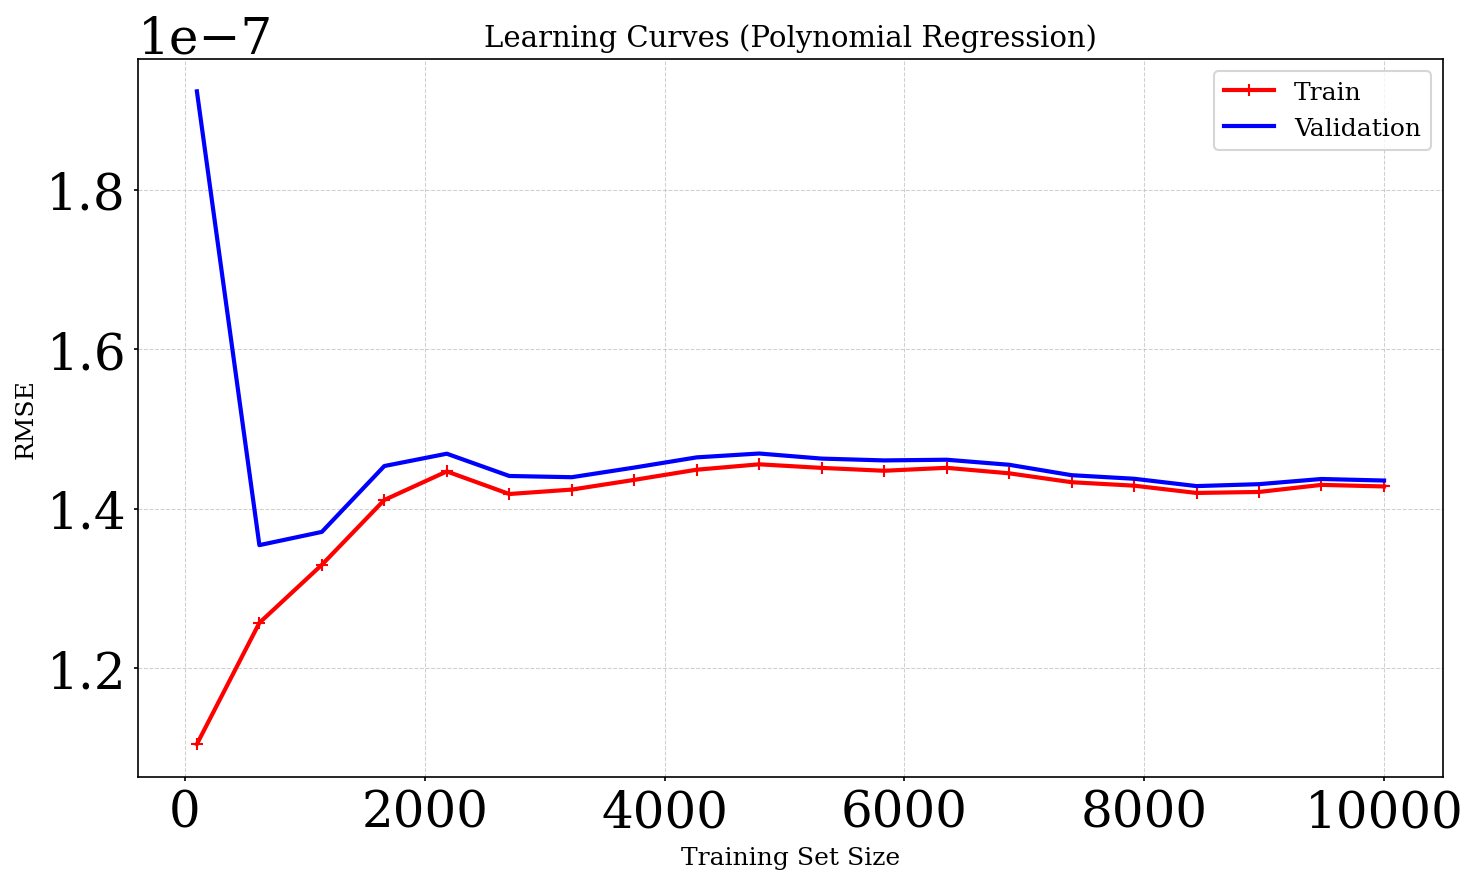

In [ ]:
def plot_learning_curves_poly_cv(X, y, scaler_X, degree=grado, cv=5):
    # 1. Usa solo el 80% de los datos para entrenamiento y validación
    X_sub, _, y_sub, _ = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Tamaños crecientes de entrenamiento
    train_sizes = np.linspace(100,10000, 20, dtype=int)

    train_errors, val_errors = [], []
    poly = PolynomialFeatures(degree=degree)

    for m in train_sizes:
        X_sample = X_sub[:m]
        y_sample = y_sub[:m]

        # Escalar X
        X_scaled = scaler_X.transform(X_sample)
        y_scaled = y_sample  # y no se escala

        # Expansión polinómica
        X_poly = poly.fit_transform(X_scaled)

        # Validación cruzada manual
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        train_rmse_fold = []
        val_rmse_fold = []

        for train_idx, val_idx in kf.split(X_poly):
            X_train_fold, X_val_fold = X_poly[train_idx], X_poly[val_idx]
            y_train_fold, y_val_fold = y_scaled[train_idx], y_scaled[val_idx]

            model = LinearRegression()
            model.fit(X_train_fold, y_train_fold)

            # Predicción
            y_train_pred = model.predict(X_train_fold)
            y_val_pred = model.predict(X_val_fold)

            # RMSE en escala original (no desescalada)
            train_rmse = np.sqrt(mean_squared_error(y_train_fold, y_train_pred))
            val_rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))

            train_rmse_fold.append(train_rmse)
            val_rmse_fold.append(val_rmse)

        # Promediar errores de los folds
        train_errors.append(np.mean(train_rmse_fold))
        val_errors.append(np.mean(val_rmse_fold))

    # 3. Graficar
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    ax.plot(train_sizes, train_errors, "r-+", linewidth=2, label="Train")
    ax.plot(train_sizes, val_errors, "b-", linewidth=2, label="Validation")

    ax.set_title("Learning Curves (Polynomial Regression)", fontsize=14)
    ax.set_xlabel("Training Set Size", fontsize=12)
    ax.set_ylabel("RMSE", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    # Opcional: ajustar ticks si tus datos son grandes


    plt.tight_layout()
    plt.savefig("learning_curve_poly_cv.png", dpi=400, bbox_inches='tight')
    plt.savefig("learning_curve_poly_cv.pdf", dpi=400, bbox_inches='tight')
    plt.savefig("learning_curve_poly_cv.eps", dpi=400, bbox_inches='tight')
    plt.show()

plot_learning_curves_poly_cv(X, y, scaler_X, degree=grado, cv=5)

# Heatmap of predictions

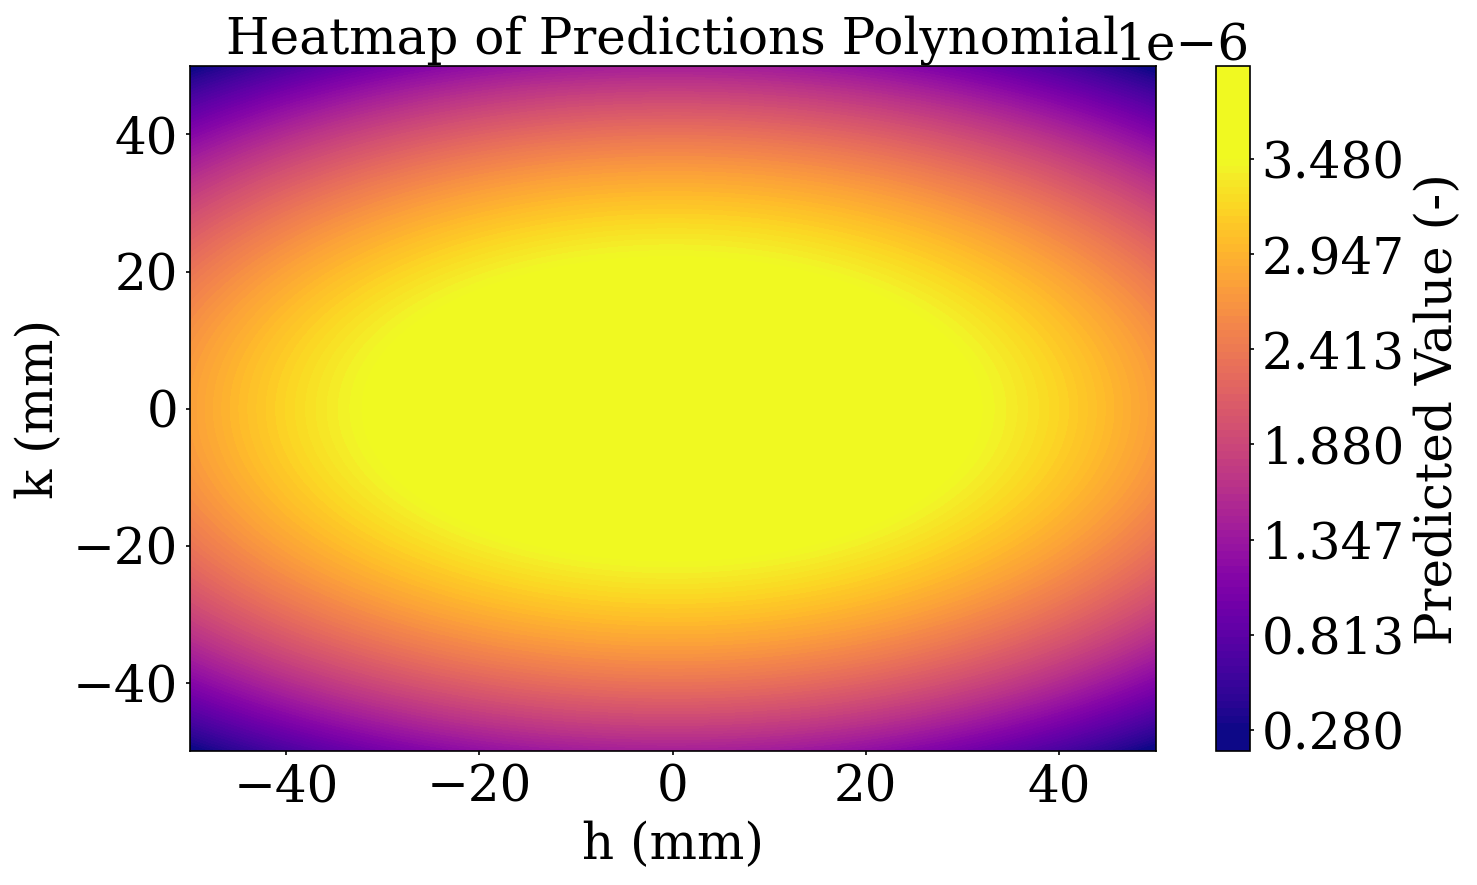

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(w, h), dpi=150)

vmin = 0.28e-6
vmax = 3.48e-6
ticks = np.linspace(vmin, vmax, 7)

contour = ax.contourf(H, K, F_poly, levels=100, vmin=vmin, vmax=vmax, cmap='plasma')
cbar = fig.colorbar(contour)
cbar.set_label(label='Predicted Value (-)', size=size_text)
cbar.set_ticks(ticks)

plt.title(f"Heatmap of Predictions Polynomial")
plt.xlabel("h (mm)", fontsize=size_text)
plt.ylabel("k (mm)", fontsize=size_text)
plt.tight_layout()

plt.savefig("Heatmap_polypredictions.png", dpi=400, bbox_inches='tight')
plt.savefig("Heatmap_polypredictions.pdf", dpi=400, bbox_inches='tight')
plt.savefig("Heatmap_polypredictions.eps", dpi=400, bbox_inches='tight')
plt.show()
